# Script to load the data and generate first insights

In [2]:
#packages

import pandas as pd
import numpy as np
import plotly

## Dataset 1 - WiFi counts

In [6]:
wifi_sept = pd.read_excel('JMH_devices_2025_sept.xlsx')
wifi_sept['timestamp'] = pd.to_datetime(wifi_sept['timestamp'])
wifi_sept.head()

,Unnamed: 0,name,site_id,map_id,num_clients,timestamp
0,0,ap-jmh-00e01-1,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,9f9ff033-3c33-4f6c-a435-0dd84e4a9749,14,2025-09-08 13:00:44
1,1,ap-jmh-00e01-3,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,9f9ff033-3c33-4f6c-a435-0dd84e4a9749,17,2025-09-08 13:00:44
2,2,ap-jmh--1D14,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,2ecc01e7-bd30-434e-bbdd-59f08b912449,0,2025-09-08 13:00:44
3,3,ap-jmh-02e31a,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,4e5994b9-01d9-4b29-87c1-27434c34d5ec,8,2025-09-08 13:00:44
4,4,ap-jmh-00e33,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,9f9ff033-3c33-4f6c-a435-0dd84e4a9749,15,2025-09-08 13:00:44


In [7]:
wifi_okt = pd.read_excel('JMH_devices_2025_oct.xlsx')
wifi_okt['timestamp'] = pd.to_datetime(wifi_okt['timestamp'])
wifi_okt.head()

,Unnamed: 0,name,site_id,map_id,num_clients,timestamp
0,0,ap-jmh-00e01-1,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,9f9ff033-3c33-4f6c-a435-0dd84e4a9749,1,2025-10-13 13:30:49
1,1,ap-jmh-00e01-3,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,9f9ff033-3c33-4f6c-a435-0dd84e4a9749,0,2025-10-13 13:30:49
2,2,ap-jmh--1D14,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,2ecc01e7-bd30-434e-bbdd-59f08b912449,6,2025-10-13 13:30:49
3,3,ap-jmh-02e31a,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,4e5994b9-01d9-4b29-87c1-27434c34d5ec,18,2025-10-13 13:30:49
4,4,ap-jmh-00e33,1fb165a2-0bf9-4283-a835-a8fc56db3e4d,9f9ff033-3c33-4f6c-a435-0dd84e4a9749,15,2025-10-13 13:30:49


In [12]:
wifi = pd.concat([wifi_sept, wifi_okt]).sort_values('timestamp')

<Axes: xlabel='timestamp'>

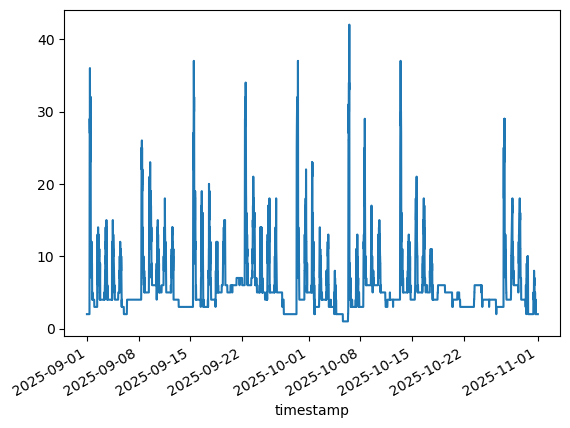

In [30]:
wifi.loc[lambda d: d.name.str.contains('jmh-05e01')].set_index('timestamp').num_clients.plot()

## Dataset 2 - CO2 and noise measurements

In [31]:
climate = pd.read_csv('Sensor Datalab 05E01.csv', sep = ';', skiprows = 2)
climate.head()

,Timestamp,Timezone : Europe/Amsterdam,Temperature,Humidity,CO2,Noise,Pressure
0,1756677674,2025/09/01 00:01:14,22.6,60,477.0,36.0,1005.5
1,1756677976,2025/09/01 00:06:16,22.6,60,459.0,36.0,1005.7
2,1756678278,2025/09/01 00:11:18,22.6,60,470.0,36.0,1005.5
3,1756678580,2025/09/01 00:16:20,22.6,60,477.0,36.0,1005.4
4,1756678882,2025/09/01 00:21:22,22.6,60,470.0,36.0,1005.4


In [32]:
climate['Timezone : Europe/Amsterdam'] = pd.to_datetime(climate['Timezone : Europe/Amsterdam'])
climate['Timestamp'] = pd.to_datetime(climate['Timestamp'], unit = 's')

climate.head()

,Timestamp,Timezone : Europe/Amsterdam,Temperature,Humidity,CO2,Noise,Pressure
0,2025-08-31 22:01:14,2025-09-01 00:01:14,22.6,60,477.0,36.0,1005.5
1,2025-08-31 22:06:16,2025-09-01 00:06:16,22.6,60,459.0,36.0,1005.7
2,2025-08-31 22:11:18,2025-09-01 00:11:18,22.6,60,470.0,36.0,1005.5
3,2025-08-31 22:16:20,2025-09-01 00:16:20,22.6,60,477.0,36.0,1005.4
4,2025-08-31 22:21:22,2025-09-01 00:21:22,22.6,60,470.0,36.0,1005.4


<Axes: xlabel='Timezone : Europe/Amsterdam'>

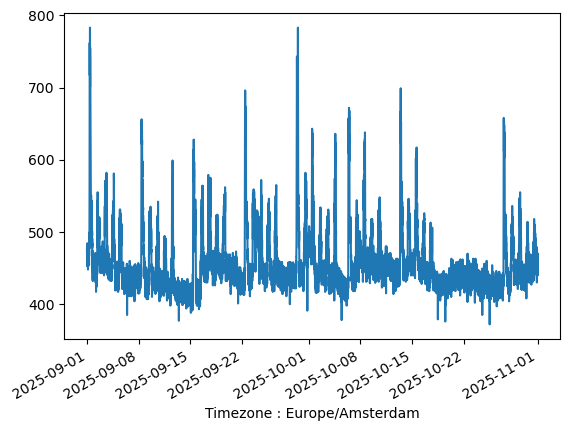

In [33]:
climate.set_index('Timezone : Europe/Amsterdam').CO2.plot()

<Axes: xlabel='Timezone : Europe/Amsterdam'>

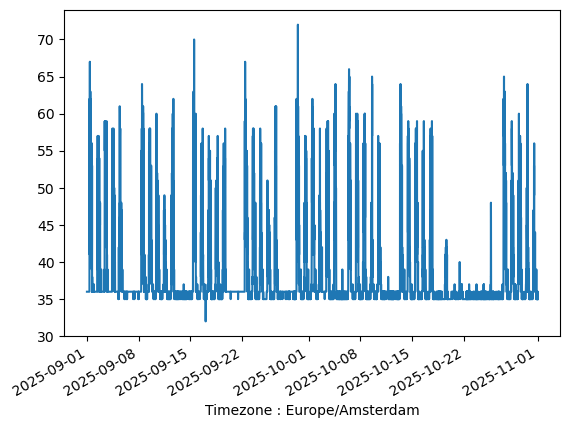

In [34]:
climate.set_index('Timezone : Europe/Amsterdam').Noise.plot()

## Dataset 3 - door counter

In [35]:
door = pd.read_csv('Door_Count_Datalab.csv')
door['timestamp'] = pd.to_datetime(door['timestamp'])
door.head()

,timestamp,name,roomId,rssi,sensorId,occupancy
0,2025-11-03 12:51:31,Datalab Lesruimte,106,-68,AC1F09FFFE0D47AB,0
1,2025-11-03 12:47:53,Datalab Kantoor,105,-70,AC1F09FFFE12D5C4,3
2,2025-11-03 12:46:31,Datalab Lesruimte,106,-69,AC1F09FFFE0D47AB,0
3,2025-11-03 12:42:53,Datalab Kantoor,105,-70,AC1F09FFFE12D5C4,3
4,2025-11-03 12:41:30,Datalab Lesruimte,106,-69,AC1F09FFFE0D47AB,0


<Axes: xlabel='timestamp'>

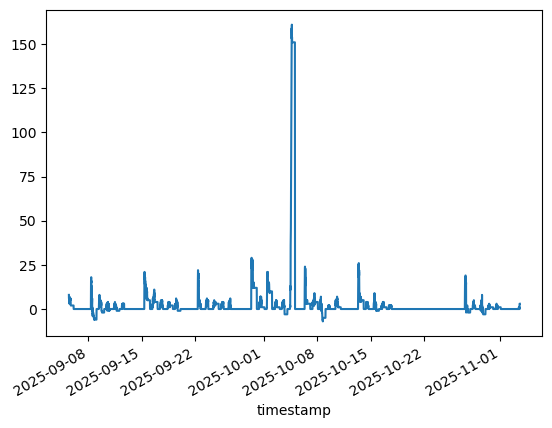

In [36]:
door.loc[lambda d: d.name.str.contains('Kantoor')].set_index('timestamp').occupancy.plot()

## Dataset 4 - human counting 

In [54]:
count = pd.read_excel('Measuremen_Counting.xlsx')
count['timestamp'] = pd.to_datetime(count.apply(lambda d: str(d['Date']) + ' ' + str(d['Time']), axis = 1), format = 'mixed')
count.head()

,Date,Time,Day,Week,Category,Period,Floor,Building,Building code,Room,Bezetting,Capacity,People count,Room function,timestamp
0,2025-09-15,08:55:00,Monday,38 2025,08:40 - 09:10,01. 08:30 - 09:20,Etage 05,Jakoba Mulderhuis,JMH,JMH 05D02,Niet bezet,NaN,NaN,Theorielokaal,2025-09-15 08:55:00
1,2025-09-15,08:56:00,Monday,38 2025,08:40 - 09:10,01. 08:30 - 09:20,Etage 05,Jakoba Mulderhuis,JMH,JMH 05D04,Bezet,32.0,12.0,Theorielokaal,2025-09-15 08:56:00
2,2025-09-15,08:56:00,Monday,38 2025,08:40 - 09:10,01. 08:30 - 09:20,Etage 05,Jakoba Mulderhuis,JMH,JMH 05D16,Niet bezet,NaN,NaN,Zelfstudieruimte,2025-09-15 08:56:00
3,2025-09-15,08:56:00,Monday,38 2025,08:40 - 09:10,01. 08:30 - 09:20,Etage 05,Jakoba Mulderhuis,JMH,JMH 05D18,Niet bezet,NaN,NaN,Zelfstudieruimte,2025-09-15 08:56:00
4,2025-09-15,08:56:00,Monday,38 2025,08:40 - 09:10,01. 08:30 - 09:20,Etage 05,Jakoba Mulderhuis,JMH,JMH 05D24,Niet bezet,NaN,NaN,Zelfstudieruimte,2025-09-15 08:56:00


<Axes: xlabel='timestamp'>

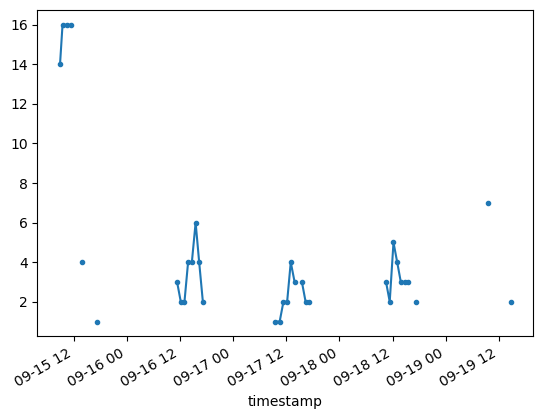

In [53]:
count.loc[lambda d: d.Room == 'JMH 05E01'].set_index('timestamp')['People count'].plot(style = '.-')

## Plot all timeseries in a single graph for Monday 15th of September 2025

N.B. the CO2 axis is hidden for clarity

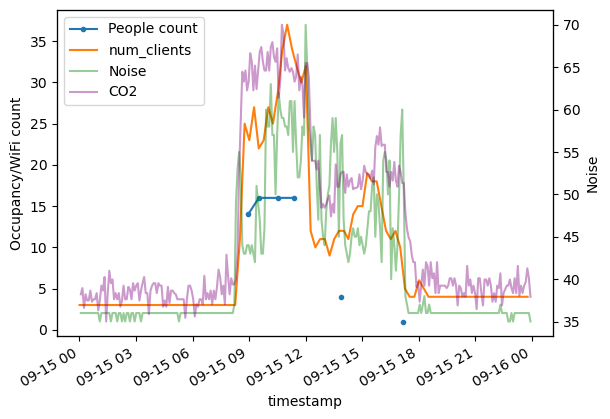

In [73]:
ax = count.loc[lambda d: d.Room == 'JMH 05E01'].set_index('timestamp').loc['2025-09-15']['People count'].plot(style = '.-')
wifi.loc[lambda d: d.name.str.contains('jmh-05e01')].set_index('timestamp').loc['2025-09-15'].num_clients.plot(ax = ax)
ax.set_ylabel('Occupancy/WiFi count')

ax2 = ax.twinx()
climate.set_index('Timezone : Europe/Amsterdam').sort_index().loc['2025-09-15'].Noise.plot(ax = ax2, color = 'green', alpha = 0.4)
ax2.set_ylabel('Noise')

ax3 = ax.twinx()
climate.set_index('Timezone : Europe/Amsterdam').sort_index().loc['2025-09-15'].CO2.plot(ax = ax3, color = 'purple', alpha = 0.4)
ax3.yaxis.set_visible(False)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')